# [6.2] Gemma Scope Deep Dive - Solutions

> **Core question:** when a released SAE feature looks semantic, what evidence shows that the coordinate is measured correctly, generalizes beyond selected examples, and has a feature-specific causal effect?

**By the end of this notebook, you will have shown that one known sparse feature is recovered exactly, separates 24 held-out examples, and causally controls a known readout while random-feature, shuffled-label, decoder-norm, density, and matched-direction controls fail. You will then compare that standard with one pinned Gemma Scope 2 result.**

```yaml
gt_tier: GT-0 exact organism followed by pinned GT-1 real-model evidence
exercise_id: 6_2_gemma_scope_deep_dive
expected_runtime: 75-100 minutes on CPU
requires_gpu: false for this notebook; CUDA is only needed to refresh the pinned real-model evidence
```

# Introduction

## Learning Objectives

By the end, you should be able to:

- load an SAE artifact and normalize decoder rows without changing its function;
- implement Gemma Scope's JumpReLU encode and decode equations;
- check reconstruction before interpreting a feature;
- score a feature on held-out examples with random-feature and shuffled-label controls;
- audit decoder norms, activation density, rare features, and dead features;
- implement feature ablation, matched-direction steering, and direct logit attribution;
- separate exact ground-truth evidence from a narrow real-model feature claim.


In [1]:
import sys
from collections.abc import Mapping
from dataclasses import dataclass
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import torch as t
from IPython.display import Markdown, display

chapter = "chapter6_sparse_feature_methods"
section = "part2_gemma_scope_deep_dive"
root_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / chapter).exists())
exercises_dir = root_dir / chapter / "exercises"
section_dir = exercises_dir / section
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))
if str(exercises_dir) not in sys.path:
    sys.path.append(str(exercises_dir))

import part2_gemma_scope_deep_dive.tests as tests
import part2_gemma_scope_deep_dive.utils as utils

GT_TIER = "GT-1"
EXERCISE_ID = "6_2_gemma_scope_deep_dive"


def show_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "|" + "|".join(["---"] * len(headers)) + "|"]
    lines.extend("| " + " | ".join(map(str, row)) + " |" for row in rows)
    display(Markdown("\n".join(lines)))


@dataclass(frozen=True)
class SparseAutoencoder:
    w_enc: t.Tensor
    w_dec: t.Tensor
    b_enc: t.Tensor
    b_dec: t.Tensor
    threshold: t.Tensor

@dataclass(frozen=True)
class ReconstructionReport:
    mse: float
    relative_mse: float
    explained_variance: float

@dataclass(frozen=True)
class HeldOutValidationReport:
    feature_auc: float
    random_feature_auc: float
    shuffled_label_auc: float
    threshold_accuracy: float
    positive_mean: float
    negative_mean: float


## Cold Open: An Organism With Known Features

Before looking at a real model, we need a case where interpretation can be wrong in detectable ways.

Our organism has six residual dimensions and six orthonormal ground-truth decoder directions. For each named text example we choose a sparse non-negative latent vector `z` and construct

\[
x = z W_{dec} + b_{dec}.
\]

The first latent is present exactly for technical text. Feature 1 is a formatting confound that is perfect on the 16 training examples but uninformative on the 24 held-out examples. Feature 3 is rare, feature 4 is a matched random control, and feature 5 is dead. The saved artifact deliberately rescales decoder rows to norms `[0.5, 2.0, 1.5, 0.75, 1.25, 3.0]` while inversely rescaling its encoder and thresholds.

This is an exact causal organism: we know the feature code, reconstruction, labels, and readout. It is not evidence about Gemma. It gives us a test that every measurement must pass before a real-model claim is credible.


In [2]:
organism = utils.make_ground_truth_organism()
heldout = ~organism["train_mask"]
print(f"examples: {len(organism['texts'])} total, {int(heldout.sum())} held out")
print(f"residuals: {tuple(organism['residuals'].shape)}; latents: {tuple(organism['latent_codes'].shape)}")
show_table(
    ["held-out text", "label", "true feature 0", "control feature 4"],
    [
        (
            organism["texts"][i],
            "technical" if organism["labels"][i] else "narrative",
            f"{organism['latent_codes'][i, 0]:.1f}",
            f"{organism['latent_codes'][i, 4]:.2f}",
        )
        for i in heldout.nonzero().flatten()[:6].tolist()
    ],
)


examples: 40 total, 24 held out
residuals: (40, 6); latents: (40, 6)


| held-out text | label | true feature 0 | control feature 4 |
|---|---|---|---|
| decode sparse activations | technical | 1.0 | 0.00 |
| the old clock chimed | narrative | 0.0 | 0.00 |
| normalize each decoder row | technical | 1.1 | 0.75 |
| leaves moved in the wind | narrative | 0.0 | 0.75 |
| rank documents by embedding | technical | 1.2 | 0.00 |
| a boat drifted downstream | narrative | 0.0 | 0.00 |

## 1. Load And Normalize The Dictionary

For each feature `j`, multiplying the decoder row by `s_j` and dividing its encoder column and threshold by `s_j` leaves the reconstruction unchanged but changes activation magnitudes. Normalize decoder rows before comparing feature activations or DLA magnitudes.

If the raw decoder norm is `n_j`, use:

\[
W_{dec,j}' = W_{dec,j} / n_j, \quad
W_{enc,:,j}' = n_j W_{enc,:,j}, \quad
b_{enc,j}' = n_j b_{enc,j}, \quad
\theta_j' = n_j \theta_j.
\]

### Exercise - implement `load_normalized_sae`

> ```yaml
> Difficulty: moderate
> Importance: high
> You should spend 10-15 minutes on this exercise.
> ```

Validate keys, shapes, finiteness, and non-zero decoder norms. Return a new `SparseAutoencoder` plus the original decoder norms. Do not mutate the artifact.

<details>
<summary>Expected output</summary>

The raw norms are `[0.50, 2.00, 1.50, 0.75, 1.25, 3.00]`; all normalized norms are `1.00`. The test also verifies that raw and normalized reconstructions agree.
</details>

<details>
<summary>Help - why rescale the threshold?</summary>

The JumpReLU gate compares preactivation with a threshold. Scaling only the encoder changes which examples cross that gate. Scale the encoder column, its bias, and its threshold together.
</details>

Common bug: normalizing `W_dec` alone. That changes reconstruction amplitudes and makes every later comparison invalid.

<details>
<summary>Solution</summary>

```python
def load_normalized_sae(
    artifact: Mapping[str, t.Tensor],
) -> tuple[SparseAutoencoder, t.Tensor]:
    """Validate SAE tensors and make every decoder row unit norm.

    Scaling an encoder column, its bias, and its JumpReLU threshold by the
    original decoder norm preserves the represented function exactly.
    """

    required = {"w_enc", "w_dec", "b_enc", "b_dec", "threshold"}
    missing = required.difference(artifact)
    if missing:
        raise KeyError(f"Missing SAE tensors: {sorted(missing)}")

    w_enc = t.as_tensor(artifact["w_enc"]).detach().clone().float()
    w_dec = t.as_tensor(artifact["w_dec"]).detach().clone().float()
    b_enc = t.as_tensor(artifact["b_enc"]).detach().clone().float()
    b_dec = t.as_tensor(artifact["b_dec"]).detach().clone().float()
    threshold = t.as_tensor(artifact["threshold"]).detach().clone().float()

    if w_enc.ndim != 2 or w_dec.ndim != 2:
        raise ValueError("w_enc and w_dec must be rank-2 tensors.")
    d_model, n_features = w_enc.shape
    if w_dec.shape != (n_features, d_model):
        raise ValueError("w_dec must have shape (n_features, d_model).")
    if b_enc.shape != (n_features,) or b_dec.shape != (d_model,):
        raise ValueError("Encoder and decoder biases have incompatible shapes.")
    if threshold.ndim == 0:
        threshold = threshold.expand(n_features).clone()
    if threshold.shape != (n_features,):
        raise ValueError("threshold must be scalar or have shape (n_features,).")
    if not all(t.isfinite(x).all() for x in (w_enc, w_dec, b_enc, b_dec, threshold)):
        raise ValueError("SAE tensors must be finite.")

    decoder_norms = w_dec.norm(dim=-1)
    if (decoder_norms <= 0).any():
        raise ValueError("Every decoder row must have non-zero norm.")
    sae = SparseAutoencoder(
        w_enc=w_enc * decoder_norms,
        w_dec=w_dec / decoder_norms[:, None],
        b_enc=b_enc * decoder_norms,
        b_dec=b_dec,
        threshold=threshold * decoder_norms,
    )
    return sae, decoder_norms
```
</details>


In [3]:
def load_normalized_sae(
    artifact: Mapping[str, t.Tensor],
) -> tuple[SparseAutoencoder, t.Tensor]:
    """Validate SAE tensors and make every decoder row unit norm.

    Scaling an encoder column, its bias, and its JumpReLU threshold by the
    original decoder norm preserves the represented function exactly.
    """

    required = {"w_enc", "w_dec", "b_enc", "b_dec", "threshold"}
    missing = required.difference(artifact)
    if missing:
        raise KeyError(f"Missing SAE tensors: {sorted(missing)}")

    w_enc = t.as_tensor(artifact["w_enc"]).detach().clone().float()
    w_dec = t.as_tensor(artifact["w_dec"]).detach().clone().float()
    b_enc = t.as_tensor(artifact["b_enc"]).detach().clone().float()
    b_dec = t.as_tensor(artifact["b_dec"]).detach().clone().float()
    threshold = t.as_tensor(artifact["threshold"]).detach().clone().float()

    if w_enc.ndim != 2 or w_dec.ndim != 2:
        raise ValueError("w_enc and w_dec must be rank-2 tensors.")
    d_model, n_features = w_enc.shape
    if w_dec.shape != (n_features, d_model):
        raise ValueError("w_dec must have shape (n_features, d_model).")
    if b_enc.shape != (n_features,) or b_dec.shape != (d_model,):
        raise ValueError("Encoder and decoder biases have incompatible shapes.")
    if threshold.ndim == 0:
        threshold = threshold.expand(n_features).clone()
    if threshold.shape != (n_features,):
        raise ValueError("threshold must be scalar or have shape (n_features,).")
    if not all(t.isfinite(x).all() for x in (w_enc, w_dec, b_enc, b_dec, threshold)):
        raise ValueError("SAE tensors must be finite.")

    decoder_norms = w_dec.norm(dim=-1)
    if (decoder_norms <= 0).any():
        raise ValueError("Every decoder row must have non-zero norm.")
    sae = SparseAutoencoder(
        w_enc=w_enc * decoder_norms,
        w_dec=w_dec / decoder_norms[:, None],
        b_enc=b_enc * decoder_norms,
        b_dec=b_dec,
        threshold=threshold * decoder_norms,
    )
    return sae, decoder_norms

tests.test_load_normalized_sae_preserves_function(SparseAutoencoder, load_normalized_sae)


All tests in `test_load_normalized_sae_preserves_function` passed!


## 2. Encode, Threshold, And Reconstruct

Gemma Scope JumpReLU SAEs center the residual stream by `b_dec`, compute preactivations, keep positive values strictly above a learned threshold, and decode the sparse activations:

\[
\tilde z = (x-b_{dec})W_{enc} + b_{enc}, \qquad
z = \operatorname{ReLU}(\tilde z)\,\mathbf{1}[\tilde z > \theta], \qquad
\hat x = zW_{dec} + b_{dec}.
\]

### Exercise - implement JumpReLU and reconstruction

> ```yaml
> Difficulty: moderate
> Importance: high
> You should spend 15-20 minutes on this exercise.
> ```

Implement `encode_jump_relu`, `reconstruct_from_features`, and a scale-aware `reconstruction_report`.

<details>
<summary>Expected output</summary>

The exact organism's recovered latents match within `1e-5`, reconstruction MSE is about `1.5e-15`, relative MSE is about `1.1e-14`, and explained variance is `1.0`.
</details>

<details>
<summary>Help - reconstruction comes before semantics</summary>

If an artifact cannot reconstruct activations at the claimed hook, its feature coordinates are not a trustworthy decomposition of those activations. Check the equation, hook, dtype, and normalization before reading top examples.
</details>

Common bug: applying ReLU after thresholding a differently scaled preactivation, or forgetting to subtract and restore `b_dec`.

<details>
<summary>Solution</summary>

```python
def encode_jump_relu(residuals: t.Tensor, sae: SparseAutoencoder) -> t.Tensor:
    """Encode residual vectors with Gemma Scope's JumpReLU convention."""

    if residuals.shape[-1] != sae.w_enc.shape[0]:
        raise ValueError("Residual width must match SAE d_model.")
    pre_acts = (residuals.float() - sae.b_dec) @ sae.w_enc + sae.b_enc
    return t.relu(pre_acts) * (pre_acts > sae.threshold)

def reconstruct_from_features(feature_acts: t.Tensor, sae: SparseAutoencoder) -> t.Tensor:
    """Decode sparse feature activations into the residual stream."""

    if feature_acts.shape[-1] != sae.w_dec.shape[0]:
        raise ValueError("Feature width must match the SAE dictionary width.")
    return feature_acts.float() @ sae.w_dec + sae.b_dec

def reconstruction_report(
    residuals: t.Tensor,
    reconstructed: t.Tensor,
) -> ReconstructionReport:
    """Report absolute and scale-aware reconstruction quality."""

    if residuals.shape != reconstructed.shape:
        raise ValueError("Residuals and reconstructions must have identical shapes.")
    residuals = residuals.float()
    reconstructed = reconstructed.float()
    mse = (residuals - reconstructed).square().mean()
    centered_energy = (residuals - residuals.mean(dim=0, keepdim=True)).square().mean()
    if centered_energy <= 0:
        raise ValueError("Explained variance is undefined for constant residuals.")
    relative_mse = mse / centered_energy
    return ReconstructionReport(
        mse=float(mse.item()),
        relative_mse=float(relative_mse.item()),
        explained_variance=float((1 - relative_mse).item()),
    )
```
</details>


In [4]:
def encode_jump_relu(residuals: t.Tensor, sae: SparseAutoencoder) -> t.Tensor:
    """Encode residual vectors with Gemma Scope's JumpReLU convention."""

    if residuals.shape[-1] != sae.w_enc.shape[0]:
        raise ValueError("Residual width must match SAE d_model.")
    pre_acts = (residuals.float() - sae.b_dec) @ sae.w_enc + sae.b_enc
    return t.relu(pre_acts) * (pre_acts > sae.threshold)

def reconstruct_from_features(feature_acts: t.Tensor, sae: SparseAutoencoder) -> t.Tensor:
    """Decode sparse feature activations into the residual stream."""

    if feature_acts.shape[-1] != sae.w_dec.shape[0]:
        raise ValueError("Feature width must match the SAE dictionary width.")
    return feature_acts.float() @ sae.w_dec + sae.b_dec

def reconstruction_report(
    residuals: t.Tensor,
    reconstructed: t.Tensor,
) -> ReconstructionReport:
    """Report absolute and scale-aware reconstruction quality."""

    if residuals.shape != reconstructed.shape:
        raise ValueError("Residuals and reconstructions must have identical shapes.")
    residuals = residuals.float()
    reconstructed = reconstructed.float()
    mse = (residuals - reconstructed).square().mean()
    centered_energy = (residuals - residuals.mean(dim=0, keepdim=True)).square().mean()
    if centered_energy <= 0:
        raise ValueError("Explained variance is undefined for constant residuals.")
    relative_mse = mse / centered_energy
    return ReconstructionReport(
        mse=float(mse.item()),
        relative_mse=float(relative_mse.item()),
        explained_variance=float((1 - relative_mse).item()),
    )

tests.test_jump_relu_recovers_exact_latents(load_normalized_sae, encode_jump_relu)
tests.test_reconstruction_is_exact(
    load_normalized_sae,
    encode_jump_relu,
    reconstruct_from_features,
    reconstruction_report,
)


All tests in `test_jump_relu_recovers_exact_latents` passed!
All tests in `test_reconstruction_is_exact` passed!


In [5]:
sae, raw_decoder_norms = load_normalized_sae(organism["raw_artifact"])
feature_acts = encode_jump_relu(organism["residuals"], sae)
reconstructed = reconstruct_from_features(feature_acts, sae)
recon = reconstruction_report(organism["residuals"], reconstructed)
print(f"maximum latent error: {(feature_acts - organism['latent_codes']).abs().max():.2e}")
print(f"reconstruction MSE: {recon.mse:.3e}")
print(f"explained variance: {recon.explained_variance:.6f}")


maximum latent error: 2.38e-07
reconstruction MSE: 1.485e-15
explained variance: 1.000000


## 3. Score Held-Out Examples

Top activating examples are discovery data. Validation data must be separate. A prompt score also needs an explicit token reduction rule: max, mean, or last token.

### Exercise - implement scoring, AUC, and held-out validation

> ```yaml
> Difficulty: moderate
> Importance: high
> You should spend 20-25 minutes on this exercise.
> ```

Implement a token reduction, tie-aware rank AUC, and a report that compares the candidate feature with a random feature and shuffled labels.

<details>
<summary>Expected output</summary>

On 24 held-out examples: feature 0 AUC `1.00`, matched random feature AUC `0.50`, shuffled-label AUC `0.50`, threshold accuracy `1.00`, positive mean `1.15`, negative mean `0.00`. Feature 1 falls from training AUC `1.00` to held-out AUC `0.50`.
</details>

<details>
<summary>Help - ties are half wins</summary>

AUC is the probability that a random positive outranks a random negative, with a tie worth one half. Average ranks make that definition exact and prevent sparse zero activations from being ordered arbitrarily.
</details>

Common bug: selecting a feature and reporting AUC on the same examples. That measures selection luck, not generalization.

<details>
<summary>Solution</summary>

```python
def feature_score_vector(
    feature_acts: t.Tensor,
    feature_id: int,
    *,
    reduction: Literal["max", "mean", "last"] = "max",
) -> t.Tensor:
    """Reduce token-level activations to one score per example."""

    if feature_id < 0 or feature_id >= feature_acts.shape[-1]:
        raise IndexError("feature_id is out of range.")
    if feature_acts.ndim == 2:
        return feature_acts[:, feature_id].float()
    if feature_acts.ndim != 3:
        raise ValueError("feature_acts must have shape (batch, features) or (batch, seq, features).")
    per_token = feature_acts[..., feature_id].float()
    if reduction == "max":
        return per_token.max(dim=-1).values
    if reduction == "mean":
        return per_token.mean(dim=-1)
    if reduction == "last":
        return per_token[:, -1]
    raise ValueError("reduction must be 'max', 'mean', or 'last'.")

def roc_auc_binary(scores: t.Tensor, labels: t.Tensor) -> float:
    """Compute binary ROC AUC from average ranks, including ties."""

    scores = scores.detach().flatten().float()
    labels = labels.detach().flatten().bool()
    if scores.numel() != labels.numel():
        raise ValueError("scores and labels must have the same length.")
    n_pos = int(labels.sum().item())
    n_neg = int((~labels).sum().item())
    if n_pos == 0 or n_neg == 0:
        raise ValueError("AUC needs at least one positive and one negative.")

    order = scores.argsort()
    sorted_scores = scores[order]
    ranks_sorted = t.empty_like(sorted_scores)
    start = 0
    while start < sorted_scores.numel():
        end = start + 1
        while end < sorted_scores.numel() and t.isclose(
            sorted_scores[end], sorted_scores[start], rtol=1e-6, atol=1e-7
        ):
            end += 1
        ranks_sorted[start:end] = (start + 1 + end) / 2
        start = end
    ranks = t.empty_like(scores)
    ranks[order] = ranks_sorted
    pos_rank_sum = ranks[labels].sum()
    auc = (pos_rank_sum - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
    return float(auc.item())

def validate_heldout_feature(
    feature_scores: t.Tensor,
    labels: t.Tensor,
    random_feature_scores: t.Tensor,
    shuffled_labels: t.Tensor,
) -> HeldOutValidationReport:
    """Compare a feature with random-feature and shuffled-label controls."""

    feature_scores = feature_scores.flatten().float()
    labels = labels.flatten().bool()
    random_feature_scores = random_feature_scores.flatten().float()
    shuffled_labels = shuffled_labels.flatten().bool()
    if not (
        feature_scores.shape
        == labels.shape
        == random_feature_scores.shape
        == shuffled_labels.shape
    ):
        raise ValueError("All held-out vectors must have identical shapes.")
    positives = feature_scores[labels]
    negatives = feature_scores[~labels]
    if positives.numel() == 0 or negatives.numel() == 0:
        raise ValueError("Held-out labels need both classes.")
    threshold = 0.5 * (positives.mean() + negatives.mean())
    predictions = feature_scores >= threshold
    return HeldOutValidationReport(
        feature_auc=roc_auc_binary(feature_scores, labels),
        random_feature_auc=roc_auc_binary(random_feature_scores, labels),
        shuffled_label_auc=roc_auc_binary(feature_scores, shuffled_labels),
        threshold_accuracy=float(predictions.eq(labels).float().mean().item()),
        positive_mean=float(positives.mean().item()),
        negative_mean=float(negatives.mean().item()),
    )
```
</details>


In [6]:
def feature_score_vector(
    feature_acts: t.Tensor,
    feature_id: int,
    *,
    reduction: Literal["max", "mean", "last"] = "max",
) -> t.Tensor:
    """Reduce token-level activations to one score per example."""

    if feature_id < 0 or feature_id >= feature_acts.shape[-1]:
        raise IndexError("feature_id is out of range.")
    if feature_acts.ndim == 2:
        return feature_acts[:, feature_id].float()
    if feature_acts.ndim != 3:
        raise ValueError("feature_acts must have shape (batch, features) or (batch, seq, features).")
    per_token = feature_acts[..., feature_id].float()
    if reduction == "max":
        return per_token.max(dim=-1).values
    if reduction == "mean":
        return per_token.mean(dim=-1)
    if reduction == "last":
        return per_token[:, -1]
    raise ValueError("reduction must be 'max', 'mean', or 'last'.")

def roc_auc_binary(scores: t.Tensor, labels: t.Tensor) -> float:
    """Compute binary ROC AUC from average ranks, including ties."""

    scores = scores.detach().flatten().float()
    labels = labels.detach().flatten().bool()
    if scores.numel() != labels.numel():
        raise ValueError("scores and labels must have the same length.")
    n_pos = int(labels.sum().item())
    n_neg = int((~labels).sum().item())
    if n_pos == 0 or n_neg == 0:
        raise ValueError("AUC needs at least one positive and one negative.")

    order = scores.argsort()
    sorted_scores = scores[order]
    ranks_sorted = t.empty_like(sorted_scores)
    start = 0
    while start < sorted_scores.numel():
        end = start + 1
        while end < sorted_scores.numel() and t.isclose(
            sorted_scores[end], sorted_scores[start], rtol=1e-6, atol=1e-7
        ):
            end += 1
        ranks_sorted[start:end] = (start + 1 + end) / 2
        start = end
    ranks = t.empty_like(scores)
    ranks[order] = ranks_sorted
    pos_rank_sum = ranks[labels].sum()
    auc = (pos_rank_sum - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
    return float(auc.item())

def validate_heldout_feature(
    feature_scores: t.Tensor,
    labels: t.Tensor,
    random_feature_scores: t.Tensor,
    shuffled_labels: t.Tensor,
) -> HeldOutValidationReport:
    """Compare a feature with random-feature and shuffled-label controls."""

    feature_scores = feature_scores.flatten().float()
    labels = labels.flatten().bool()
    random_feature_scores = random_feature_scores.flatten().float()
    shuffled_labels = shuffled_labels.flatten().bool()
    if not (
        feature_scores.shape
        == labels.shape
        == random_feature_scores.shape
        == shuffled_labels.shape
    ):
        raise ValueError("All held-out vectors must have identical shapes.")
    positives = feature_scores[labels]
    negatives = feature_scores[~labels]
    if positives.numel() == 0 or negatives.numel() == 0:
        raise ValueError("Held-out labels need both classes.")
    threshold = 0.5 * (positives.mean() + negatives.mean())
    predictions = feature_scores >= threshold
    return HeldOutValidationReport(
        feature_auc=roc_auc_binary(feature_scores, labels),
        random_feature_auc=roc_auc_binary(random_feature_scores, labels),
        shuffled_label_auc=roc_auc_binary(feature_scores, shuffled_labels),
        threshold_accuracy=float(predictions.eq(labels).float().mean().item()),
        positive_mean=float(positives.mean().item()),
        negative_mean=float(negatives.mean().item()),
    )

tests.test_feature_score_reductions(feature_score_vector)
tests.test_auc_and_heldout_controls(
    roc_auc_binary,
    validate_heldout_feature,
    load_normalized_sae,
    encode_jump_relu,
)


All tests in `test_feature_score_reductions` passed!
All tests in `test_auc_and_heldout_controls` passed!


In [7]:
target_scores = feature_score_vector(feature_acts, organism["target_feature_id"])
control_scores = feature_score_vector(feature_acts, organism["control_feature_id"])
validation = validate_heldout_feature(
    target_scores[heldout],
    organism["labels"][heldout],
    control_scores[heldout],
    organism["shuffled_labels"][heldout],
)
train_confound_auc = roc_auc_binary(
    feature_acts[organism["train_mask"], 1], organism["labels"][organism["train_mask"]]
)
heldout_confound_auc = roc_auc_binary(feature_acts[heldout, 1], organism["labels"][heldout])
show_table(
    ["measurement", "value"],
    [
        ("target held-out AUC", f"{validation.feature_auc:.2f}"),
        ("random-feature AUC", f"{validation.random_feature_auc:.2f}"),
        ("shuffled-label AUC", f"{validation.shuffled_label_auc:.2f}"),
        ("threshold accuracy", f"{validation.threshold_accuracy:.2f}"),
        ("confound train -> held-out AUC", f"{train_confound_auc:.2f} -> {heldout_confound_auc:.2f}"),
    ],
)


| measurement | value |
|---|---|
| target held-out AUC | 1.00 |
| random-feature AUC | 0.50 |
| shuffled-label AUC | 0.50 |
| threshold accuracy | 1.00 |
| confound train -> held-out AUC | 1.00 -> 0.50 |

## 4. Audit Density And Dead Features

Activation density is the fraction of token or example positions where a feature is positive. A dead feature cannot support a semantic claim; a rare feature needs enough independent examples; a very dense feature may encode a broad nuisance factor.

### Exercise - implement `activation_density`

> ```yaml
> Difficulty: easy
> Importance: high
> You should spend 5-10 minutes on this exercise.
> ```

Flatten every sample axis, keep the feature axis, and return both density and a dead-feature mask.

<details>
<summary>Expected output</summary>

Densities are `[0.500, 0.500, 0.650, 0.075, 0.500, 0.000]`; feature 5 is dead and feature 3 fires on only 3 of 40 examples.
</details>

<details>
<summary>Help - density is a denominator</summary>

Ten compelling examples mean something different for a feature that fires 10 times in a million tokens and one that fires on every other token. Always record the denominator.
</details>

Common bug: calculating density only over non-zero rows, which guarantees every retained feature looks alive.

<details>
<summary>Solution</summary>

```python
def activation_density(feature_acts: t.Tensor) -> tuple[t.Tensor, t.Tensor]:
    """Return per-feature firing density and a dead-feature mask."""

    if feature_acts.ndim < 2:
        raise ValueError("feature_acts needs at least one sample axis and one feature axis.")
    flat = feature_acts.reshape(-1, feature_acts.shape[-1])
    density = (flat > 0).float().mean(dim=0)
    return density, density == 0
```
</details>


In [8]:
def activation_density(feature_acts: t.Tensor) -> tuple[t.Tensor, t.Tensor]:
    """Return per-feature firing density and a dead-feature mask."""

    if feature_acts.ndim < 2:
        raise ValueError("feature_acts needs at least one sample axis and one feature axis.")
    flat = feature_acts.reshape(-1, feature_acts.shape[-1])
    density = (flat > 0).float().mean(dim=0)
    return density, density == 0

tests.test_density_finds_rare_and_dead_features(activation_density)


All tests in `test_density_finds_rare_and_dead_features` passed!


## 5. Intervene With Matched Controls

The known behavior readout is the projection onto decoder direction 0. We can therefore distinguish a causal target feature from an equally large irrelevant intervention.

### Exercise - implement ablation and steering

> ```yaml
> Difficulty: moderate
> Importance: high
> You should spend 15-20 minutes on this exercise.
> ```

`ablate_feature` zeros one cached coordinate without mutating the cache. `steer_residuals` normalizes any supplied direction before applying each strength, so target and control interventions have equal L2 size.

<details>
<summary>Expected output</summary>

On positive held-out examples, target ablation changes the readout by `1.15`; feature-4 ablation changes it by approximately `0.00`. Steering strengths `[-1, -0.5, 0, 0.5, 1]` change the target readout by the same values, while the matched control remains at zero.
</details>

<details>
<summary>Help - match intervention size</summary>

A random direction is not a useful control if its norm is smaller. Normalize both directions, use the same positions and strengths, and evaluate the same readout.
</details>

Common bug: editing cached activations in place. Later baselines then contain the intervention and silently shrink the measured effect.

<details>
<summary>Solution</summary>

```python
def ablate_feature(feature_acts: t.Tensor, feature_id: int) -> t.Tensor:
    """Set one feature coordinate to zero without mutating the input."""

    if feature_id < 0 or feature_id >= feature_acts.shape[-1]:
        raise IndexError("feature_id is out of range.")
    ablated = feature_acts.clone()
    ablated[..., feature_id] = 0
    return ablated

def steer_residuals(
    residuals: t.Tensor,
    direction: t.Tensor,
    strengths: t.Tensor | list[float],
) -> t.Tensor:
    """Add equal-L2 interventions by normalizing the supplied direction."""

    direction = t.as_tensor(direction, dtype=residuals.dtype, device=residuals.device)
    if direction.ndim != 1 or direction.shape[0] != residuals.shape[-1]:
        raise ValueError("direction must be a vector with residual width.")
    norm = direction.norm()
    if norm <= 0:
        raise ValueError("direction must be non-zero.")
    unit_direction = direction / norm
    strengths = t.as_tensor(strengths, dtype=residuals.dtype, device=residuals.device).flatten()
    view_shape = (strengths.numel(),) + (1,) * residuals.ndim
    return residuals.unsqueeze(0) + strengths.view(view_shape) * unit_direction
```
</details>


In [9]:
def ablate_feature(feature_acts: t.Tensor, feature_id: int) -> t.Tensor:
    """Set one feature coordinate to zero without mutating the input."""

    if feature_id < 0 or feature_id >= feature_acts.shape[-1]:
        raise IndexError("feature_id is out of range.")
    ablated = feature_acts.clone()
    ablated[..., feature_id] = 0
    return ablated

def steer_residuals(
    residuals: t.Tensor,
    direction: t.Tensor,
    strengths: t.Tensor | list[float],
) -> t.Tensor:
    """Add equal-L2 interventions by normalizing the supplied direction."""

    direction = t.as_tensor(direction, dtype=residuals.dtype, device=residuals.device)
    if direction.ndim != 1 or direction.shape[0] != residuals.shape[-1]:
        raise ValueError("direction must be a vector with residual width.")
    norm = direction.norm()
    if norm <= 0:
        raise ValueError("direction must be non-zero.")
    unit_direction = direction / norm
    strengths = t.as_tensor(strengths, dtype=residuals.dtype, device=residuals.device).flatten()
    view_shape = (strengths.numel(),) + (1,) * residuals.ndim
    return residuals.unsqueeze(0) + strengths.view(view_shape) * unit_direction

tests.test_ablation_has_matched_feature_control(
    ablate_feature,
    load_normalized_sae,
    encode_jump_relu,
    reconstruct_from_features,
)
tests.test_steering_normalizes_direction(steer_residuals)


All tests in `test_ablation_has_matched_feature_control` passed!
All tests in `test_steering_normalizes_direction` passed!


## 6. Generate A Direct-Logit Hypothesis

Direct logit attribution projects each decoder direction through an unembedding matrix. It suggests tokens a feature can directly promote or suppress. It does not show that the feature activates on the corresponding text or that the model uses it causally.

### Exercise - implement `direct_logit_attribution`

> ```yaml
> Difficulty: easy
> Importance: high
> You should spend 5-10 minutes on this exercise.
> ```

Support the full vocabulary matrix and optional token indexing.

<details>
<summary>Expected output</summary>

For feature 0, effects are `[1.2, -1.0, 0.9, -0.7, 0.0, 0.0]`. Its two strongest positive tokens are ` code` and ` function`; its strongest negative token is ` story`.
</details>

<details>
<summary>Help - DLA is one edge of the graph</summary>

The decoder-to-unembedding product describes a direct linear route. LayerNorm, later layers, competing features, and prompt-dependent activation can all change the final output.
</details>

Common bug: comparing DLA magnitudes before normalizing decoder rows. Raw decoder norm then masquerades as token relevance.

<details>
<summary>Solution</summary>

```python
def direct_logit_attribution(
    decoder_vectors: t.Tensor,
    unembedding: t.Tensor,
    token_ids: t.Tensor | list[int] | None = None,
) -> t.Tensor:
    """Project decoder directions through an unembedding matrix."""

    if decoder_vectors.ndim != 2 or unembedding.ndim != 2:
        raise ValueError("decoder_vectors and unembedding must be rank-2.")
    if decoder_vectors.shape[-1] != unembedding.shape[0]:
        raise ValueError("Decoder width must match the unembedding input width.")
    effects = decoder_vectors.float() @ unembedding.float()
    if token_ids is None:
        return effects
    return effects[:, t.as_tensor(token_ids, device=effects.device)]
```
</details>


In [10]:
def direct_logit_attribution(
    decoder_vectors: t.Tensor,
    unembedding: t.Tensor,
    token_ids: t.Tensor | list[int] | None = None,
) -> t.Tensor:
    """Project decoder directions through an unembedding matrix."""

    if decoder_vectors.ndim != 2 or unembedding.ndim != 2:
        raise ValueError("decoder_vectors and unembedding must be rank-2.")
    if decoder_vectors.shape[-1] != unembedding.shape[0]:
        raise ValueError("Decoder width must match the unembedding input width.")
    effects = decoder_vectors.float() @ unembedding.float()
    if token_ids is None:
        return effects
    return effects[:, t.as_tensor(token_ids, device=effects.device)]

tests.test_direct_logit_attribution_has_known_tokens(direct_logit_attribution, load_normalized_sae)


All tests in `test_direct_logit_attribution_has_known_tokens` passed!


## Signature Result

The figure below is generated from the exact organism by the functions you implemented. It combines the semantic test, coordinate audit, sparsity audit, and causal intervention in one result. The examples table keeps the claim tied to actual inputs rather than a scalar report.

<details>
<summary>Expected output</summary>

The target feature is perfect on held-out data while both controls are at chance. Raw decoder norms vary sixfold and normalize to one. Feature 5 is dead. The target steering curve has slope one while the matched random direction is flat. Target/control ablation deltas are `1.15 / 0.00`.
</details>

<details>
<summary>Interpreting the result</summary>

Feature 0 passes because it reconstructs exactly, preserves its meaning on held-out examples, and moves the known readout under a matched intervention. Feature 1 is the warning: its training AUC is perfect, but held-out AUC is chance. Feature 5 is not interpretable evidence because it never fires.
</details>


| top held-out example | label | activation |
|---|---|---|
| run the CPU unit test | technical | 1.30 |
| sweep the steering coefficient | technical | 1.30 |
| apply a forward hook | technical | 1.30 |
| rank documents by embedding | technical | 1.20 |
| ablate one learned feature | technical | 1.20 |

| DLA token | effect |
|---|---|
|  code | +1.20 |
|  function | +0.90 |
|  neutral | +0.00 |
|  syntax | -0.00 |
|  river | -0.70 |
|  story | -1.00 |

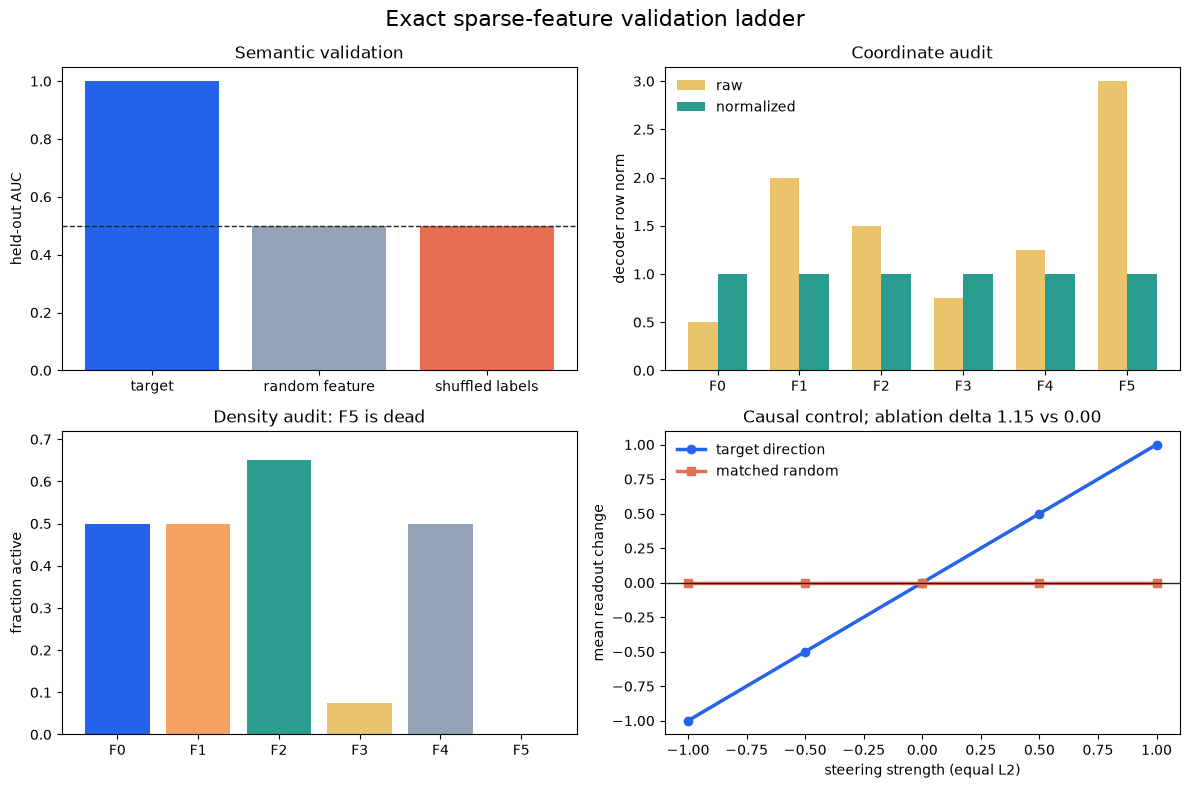

All tests in `test_ground_truth_contract` passed!
saved chapter6_sparse_feature_methods/instructions/assets/gemma_scope_ground_truth_signature.png


In [11]:
density, dead = activation_density(feature_acts)
target_id = organism["target_feature_id"]
control_id = organism["control_feature_id"]
positive_heldout = heldout & organism["labels"]
readout = sae.w_dec[target_id]
baseline_behavior = (organism["residuals"] - sae.b_dec) @ readout

target_recon = reconstruct_from_features(ablate_feature(feature_acts, target_id), sae)
control_recon = reconstruct_from_features(ablate_feature(feature_acts, control_id), sae)
target_behavior = (target_recon - sae.b_dec) @ readout
control_behavior = (control_recon - sae.b_dec) @ readout
target_ablation_delta = float(
    (baseline_behavior[positive_heldout] - target_behavior[positive_heldout]).mean()
)
control_ablation_delta = float(
    (baseline_behavior[positive_heldout] - control_behavior[positive_heldout]).mean()
)
if abs(control_ablation_delta) < 1e-6:
    control_ablation_delta = 0.0

strengths = t.tensor([-1.0, -0.5, 0.0, 0.5, 1.0])
target_steered = steer_residuals(organism["residuals"], sae.w_dec[target_id], strengths)
control_steered = steer_residuals(organism["residuals"], sae.w_dec[control_id], strengths)
baseline_mean = baseline_behavior.mean()
target_curve = ((target_steered - sae.b_dec) @ readout).mean(dim=1) - baseline_mean
control_curve = ((control_steered - sae.b_dec) @ readout).mean(dim=1) - baseline_mean
control_curve = t.where(control_curve.abs() < 1e-6, 0.0, control_curve)
dla = direct_logit_attribution(sae.w_dec, organism["unembedding"])

heldout_indices = heldout.nonzero().flatten()
top_local = target_scores[heldout].topk(5).indices
show_table(
    ["top held-out example", "label", "activation"],
    [
        (
            organism["texts"][heldout_indices[i]],
            "technical" if organism["labels"][heldout_indices[i]] else "narrative",
            f"{target_scores[heldout_indices[i]]:.2f}",
        )
        for i in top_local.tolist()
    ],
)
show_table(
    ["DLA token", "effect"],
    [
        (organism["token_names"][i], f"{dla[target_id, i]:+.2f}")
        for i in dla[target_id].argsort(descending=True).tolist()
    ],
)

labels = [f"F{i}" for i in range(6)]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].bar(
    ["target", "random feature", "shuffled labels"],
    [validation.feature_auc, validation.random_feature_auc, validation.shuffled_label_auc],
    color=["#2563eb", "#94a3b8", "#e76f51"],
)
axes[0, 0].axhline(0.5, color="#222222", linestyle="--", linewidth=1)
axes[0, 0].set_ylim(0, 1.05)
axes[0, 0].set_ylabel("held-out AUC")
axes[0, 0].set_title("Semantic validation")

x = t.arange(6).numpy()
axes[0, 1].bar(x - 0.18, raw_decoder_norms.numpy(), width=0.36, label="raw", color="#e9c46a")
axes[0, 1].bar(
    x + 0.18,
    sae.w_dec.norm(dim=-1).numpy(),
    width=0.36,
    label="normalized",
    color="#2a9d8f",
)
axes[0, 1].set_xticks(x, labels)
axes[0, 1].set_ylabel("decoder row norm")
axes[0, 1].set_title("Coordinate audit")
axes[0, 1].legend(frameon=False)

axes[1, 0].bar(labels, density.numpy(), color=["#2563eb", "#f4a261", "#2a9d8f", "#e9c46a", "#94a3b8", "#d62828"])
axes[1, 0].set_ylim(0, 0.72)
axes[1, 0].set_ylabel("fraction active")
axes[1, 0].set_title("Density audit: F5 is dead")

axes[1, 1].plot(strengths, target_curve, marker="o", linewidth=2.5, label="target direction", color="#2563eb")
axes[1, 1].plot(strengths, control_curve, marker="s", linewidth=2.5, label="matched random", color="#e76f51")
axes[1, 1].axhline(0, color="#222222", linewidth=1)
axes[1, 1].set_xlabel("steering strength (equal L2)")
axes[1, 1].set_ylabel("mean readout change")
axes[1, 1].set_title(
    f"Causal control; ablation delta {target_ablation_delta:.2f} vs {control_ablation_delta:.2f}"
)
axes[1, 1].legend(frameon=False)

fig.suptitle("Exact sparse-feature validation ladder", fontsize=16)
fig.tight_layout()
plt.show()

analysis = {
    "reconstruction": recon.__dict__,
    "raw_decoder_norms": raw_decoder_norms.tolist(),
    "normalized_decoder_norms": sae.w_dec.norm(dim=-1).tolist(),
    "density": density.tolist(),
    "dead_feature_ids": dead.nonzero().flatten().tolist(),
    "validation": validation.__dict__,
    "train_confound_auc": train_confound_auc,
    "heldout_confound_auc": heldout_confound_auc,
    "target_ablation_delta": target_ablation_delta,
    "control_ablation_delta": control_ablation_delta,
    "steering_strengths": strengths.tolist(),
    "target_steering_delta": target_curve.tolist(),
    "control_steering_delta": control_curve.tolist(),
    "target_dla": dla[target_id].tolist(),
}
tests.test_ground_truth_contract(lambda cpu=True: analysis)


asset_path = root_dir / chapter / "instructions/assets/gemma_scope_ground_truth_signature.png"
fig.savefig(asset_path, dpi=180, bbox_inches="tight")
print(f"saved {asset_path.relative_to(root_dir)}")


## Try It Yourself: Feature Audition

Change `feature_id`. A plausible feature should keep working when you move from the training split to held-out examples. Feature 1 is the intended anomaly.


In [12]:
feature_id = 1  # Try 0 through 5.
scores = feature_score_vector(feature_acts, feature_id)
train_auc = roc_auc_binary(scores[organism["train_mask"]], organism["labels"][organism["train_mask"]])
test_auc = roc_auc_binary(scores[heldout], organism["labels"][heldout])
top_ids = scores.topk(4).indices.tolist()
print(f"{organism['feature_names'][feature_id]}: train AUC={train_auc:.2f}, held-out AUC={test_auc:.2f}")
for i in top_ids:
    print(f"  {scores[i]:.2f}  {organism['texts'][i]}")


train-only formatting confound: train AUC=1.00, held-out AUC=0.50
  0.90  multiply the matrix by W
  0.90  compute cosine similarity
  0.90  cache the residual stream
  0.90  mask padding tokens


## Try It Yourself: Intervention Sweep

Change the strengths, target feature, or control feature. Keep target and control directions normalized and compare the same readout.


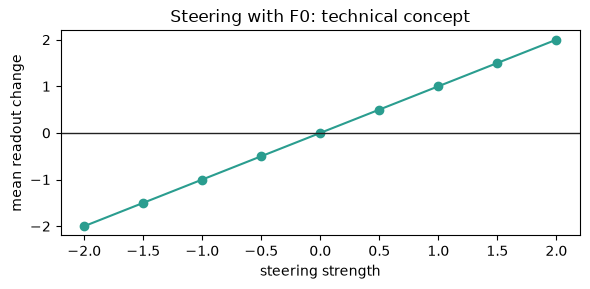

In [13]:
play_strengths = t.linspace(-2, 2, 9)
play_feature_id = 0
play_direction = sae.w_dec[play_feature_id]
play_residuals = steer_residuals(organism["residuals"], play_direction, play_strengths)
play_curve = ((play_residuals - sae.b_dec) @ readout).mean(dim=1) - baseline_mean
plt.figure(figsize=(6, 3))
plt.plot(play_strengths, play_curve, marker="o", color="#2a9d8f")
plt.axhline(0, color="#222222", linewidth=1)
plt.xlabel("steering strength")
plt.ylabel("mean readout change")
plt.title(f"Steering with F{play_feature_id}: {organism['feature_names'][play_feature_id]}")
plt.tight_layout()
plt.show()


## Anomaly Hunting

Three anomalies are planted deliberately:

1. **Selection overfit:** feature 1 has training AUC `1.00` and held-out AUC `0.50`.
2. **Rare evidence:** feature 3 fires on only `7.5%` of examples. Inspect all three before naming it.
3. **Dead coordinate:** feature 5 has density `0.0`; its decoder and DLA still exist, but there are no activation examples supporting a semantic interpretation.

Use the next cell to list every activation for a suspicious feature. A real Gemma Scope analysis should repeat this audit across datasets, prompt lengths, token positions, layers, and artifact widths.


In [14]:
suspicious_feature_id = 3
active_ids = (feature_acts[:, suspicious_feature_id] > 0).nonzero().flatten().tolist()
print(f"F{suspicious_feature_id} density = {density[suspicious_feature_id]:.3f}")
for i in active_ids:
    print(f"  {feature_acts[i, suspicious_feature_id]:.2f}  {organism['texts'][i]}")


F3 density = 0.075
  1.10  a child watched the clouds
  1.10  apply a forward hook
  1.10  a violin played next door


## Escalation To Pinned Gemma Scope Evidence

Only now do we inspect the committed real-model evidence. This CPU cell reads a strict record; it does not download a model, run CUDA, or substitute another artifact. The record pins:

- Gemma Scope 2 repository `google/gemma-scope-2-1b-it` at revision `b0fa29457c3601df0a70c48a15534c738d7c10e0`;
- residual JumpReLU SAE `resid_post/layer_13_width_16k_l0_small` with `d_model=1152`, width `16384`;
- Gemma 3 1B IT at revision `dcc83ea841ab6100d6b47a070329e1ba4cf78752`;
- one benign technical-ML-tool-text versus narrative-prose feature selected on 8 prompts and evaluated on 8 held-out prompts.

This is a narrow semantic result. It does not contain a real-model ablation or steering experiment, and eight held-out prompts are too few for a broad feature claim.

<details>
<summary>Expected output</summary>

Feature `15586` has held-out AUC `1.000`, random feature `7121` has AUC `0.500`, shuffled-label AUC is `0.000`, threshold accuracy is `0.750`, and positive/negative mean activations are `240.36 / 102.72`. Peak CUDA memory should remain below `2.3 GB`.
</details>

<details>
<summary>Help - why keep this after the exact result?</summary>

The exact organism proves the analysis code can recover truth and reject planted traps. The pinned run shows the same measurement shape works on one real artifact. Neither result upgrades the other beyond its evidence.
</details>


In [15]:
gpu = utils.load_pinned_real_evidence(section_dir)
real = gpu["gemma_scope_real_activation_preflight"]
show_table(
    ["pinned real-model field", "value"],
    [
        ("artifact", gpu["gemma_scope_artifact_path"]),
        ("encoder / decoder", f"{gpu['gemma_scope_w_enc_shape']} / {gpu['gemma_scope_w_dec_shape']}"),
        ("train / held-out prompts", f"{real['train_prompt_count']} / {real['heldout_prompt_count']}"),
        ("selected / random feature", f"{real['selected_feature_id']} / {real['random_control_feature_id']}"),
        ("held-out target / random / shuffle AUC", f"{real['feature_auc']:.3f} / {real['baseline_auc']:.3f} / {real['label_shuffle_auc']:.3f}"),
        ("threshold accuracy", f"{real['threshold_accuracy']:.3f}"),
        ("positive / negative mean", f"{real['positive_mean']:.2f} / {real['negative_mean']:.2f}"),
        ("active features per prompt-token", f"{real['active_features_per_prompt_token']:.1f}"),
        ("prompted reconstruction MSE", f"{real['prompted_reconstruction_mse']:.1f} (not scale-normalized)"),
        ("peak CUDA memory", f"{gpu['peak_vram_gb']:.2f} GB (< 2.3 GB)"),
    ],
)


| pinned real-model field | value |
|---|---|
| artifact | resid_post/layer_13_width_16k_l0_small |
| encoder / decoder | [1152, 16384] / [16384, 1152] |
| train / held-out prompts | 8 / 8 |
| selected / random feature | 15586 / 7121 |
| held-out target / random / shuffle AUC | 1.000 / 0.500 / 0.000 |
| threshold accuracy | 0.750 |
| positive / negative mean | 240.36 / 102.72 |
| active features per prompt-token | 1627.9 |
| prompted reconstruction MSE | 6754145.0 (not scale-normalized) |
| peak CUDA memory | 2.24 GB (< 2.3 GB) |

## Optional CUDA Refresh Contract

`verification_report.json` is a historical record of the pinned CUDA run. It is
supporting evidence, not the signature result. Maintainers with the exact gated
model access can refresh it through these entry points; the learner notebook
never calls them automatically.


In [16]:
def run_gpu_test(max_vram_gb: float = 24.0) -> dict:
    from part2_gemma_scope_deep_dive import solutions as reference_solutions

    return reference_solutions.run_gpu_test(max_vram_gb=max_vram_gb)


def run_full_experiment(max_vram_gb: float = 24.0) -> dict:
    return run_gpu_test(max_vram_gb=max_vram_gb)


## Limitations

- The exact organism is linear, orthogonal, and noiseless. Real SAEs are overcomplete, features interfere, thresholds vary, and reconstruction error is non-zero.
- Text labels in the organism are assigned by construction. Real semantic labels require a written rubric, independent annotators where feasible, and larger held-out and out-of-distribution sets.
- AUC does not measure calibration and can hide subgroup failures. Inspect score distributions and concrete false positives and negatives.
- DLA is a direct linear contribution, not a full causal path through later layers.
- The pinned Gemma Scope result uses 16 prompts total, with 8 held out, one layer, one SAE width, and one selected feature. Its shuffled-label AUC of `0.0` is one small-sample permutation, not a null distribution.
- The pinned result has no real-model steering or ablation, so the real feature claim remains correlational.

## Further Research

1. Pre-register 50 or more held-out prompts and matched lexical controls before selecting a Gemma feature.
2. Repeat across artifact widths and nearby layers, recording decoder norms and density each time.
3. Run many label permutations to form a null distribution rather than reporting one shuffle.
4. Add equal-norm random-direction ablation and steering, plus a language-model loss or perplexity side-effect curve.
5. Inspect the largest false positives, false negatives, rare features, and dead features before writing a semantic label.

## Reading And Model Links

- [Gemma Scope paper](https://arxiv.org/abs/2408.05147)
- [Gemma Scope 2 model collection](https://huggingface.co/google/gemma-scope-2-1b-it)
- [Pinned layer-13 artifact](https://huggingface.co/google/gemma-scope-2-1b-it/tree/b0fa29457c3601df0a70c48a15534c738d7c10e0/resid_post/layer_13_width_16k_l0_small)
- [Google DeepMind Gemma Scope overview](https://deepmind.google/models/gemma/gemma-scope/)
- [Original ARENA SAE exercises](https://arena-chapter1-transformer-interp.streamlit.app/)
